# **MÓDULO 19**
# Exercício: Estatística Aplicada

**Efetividade de Duas Estratégias de Ensino**

Imagine que uma escola esteja avaliando a eficácia de duas estratégias de ensino de matemática para alunos do ensino médio. Eles querem determinar se há uma diferença significativa no desempenho médio dos alunos entre as duas estratégias.

# **Hipóteses:**

* Hipótese nula (H0): A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B.
* Hipótese alternativa (H1): A média das notas na Estratégia B é maior do que a média das notas na Estratégia A.

# **Dados:**

* Amostra da Estratégia A: Notas de 50 alunos que receberam a Estratégia A.
* Amostra da Estratégia B: Notas de 50 alunos que receberam a Estratégia B.

Usaremos um teste Z para comparar as médias das notas entre as duas amostras.

Se o p-valor do teste Z for menor que um nível de significância pré-determinado (por exemplo, α = 0.05), rejeitamos a hipótese nula e concluímos que há uma diferença significativa nas médias das notas entre as duas estratégias de ensino.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Os dados são criados a seguir:

In [2]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.




In [3]:
# 1) Justificativa
resposta_1 = '''
O teste é unilateral à direita.

Justificativa: a hipótese alternativa afirma que a média das notas da Estratégia B é maior
do que a média das notas da Estratégia A, isto é: H1: μB > μA. Portanto, a região
crítica fica na cauda direita da distribuição, pois estamos procurando evidência de que
a diferença média (B - A) seja positiva e suficientemente grande.
'''
print(resposta_1)



O teste é unilateral à direita.

Justificativa: a hipótese alternativa afirma que a média das notas da Estratégia B é maior
do que a média das notas da Estratégia A, isto é: H1: μB > μA. Portanto, a região
crítica fica na cauda direita da distribuição, pois estamos procurando evidência de que
a diferença média (B - A) seja positiva e suficientemente grande.



# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [4]:
# 2) Médias e variâncias das duas amostras
media_A = np.mean(amostra_estrategia_A)
media_B = np.mean(amostra_estrategia_B)

# Variância amostral: ddof=1
var_A = np.var(amostra_estrategia_A, ddof=1)
var_B = np.var(amostra_estrategia_B, ddof=1)

print(f'Média da Estratégia A: {media_A:.2f}')
print(f'Média da Estratégia B: {media_B:.2f}')
print(f'Variância amostral da Estratégia A: {var_A:.2f}')
print(f'Variância amostral da Estratégia B: {var_B:.2f}')

print('''
Insights:
- A média da Estratégia B é maior do que a média da Estratégia A na amostra.
- A diferença observada entre as médias é de aproximadamente {:.2f} pontos.
- A variância da Estratégia A ficou um pouco maior do que a da Estratégia B nesta amostra,
  indicando maior dispersão das notas em A nos dados observados.
- Apesar da média de B ser maior, ainda é necessário verificar pelo teste estatístico
  se essa diferença é significativa ao nível de 5%.
'''.format(media_B - media_A))


Média da Estratégia A: 71.41
Média da Estratégia B: 74.75
Variância amostral da Estratégia A: 129.27
Variância amostral da Estratégia B: 110.47

Insights:
- A média da Estratégia B é maior do que a média da Estratégia A na amostra.
- A diferença observada entre as médias é de aproximadamente 3.34 pontos.
- A variância da Estratégia A ficou um pouco maior do que a da Estratégia B nesta amostra,
  indicando maior dispersão das notas em A nos dados observados.
- Apesar da média de B ser maior, ainda é necessário verificar pelo teste estatístico
  se essa diferença é significativa ao nível de 5%.



# 3) Antes de aplicar o teste Z, verifique a normalidade das duas amostras. Depois, imprima os resultados da estatística do teste Z, p-value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.


In [5]:
# 3) Teste de normalidade, estatística Z, p-valor e decisão do teste
alpha = 0.05
n_A = len(amostra_estrategia_A)
n_B = len(amostra_estrategia_B)

# ------------------------------------------------------------
# Teste de normalidade de Shapiro-Wilk
# H0 do Shapiro-Wilk: os dados seguem uma distribuição normal
# H1 do Shapiro-Wilk: os dados não seguem uma distribuição normal
# ------------------------------------------------------------
shapiro_A = stats.shapiro(amostra_estrategia_A)
shapiro_B = stats.shapiro(amostra_estrategia_B)

print('--- Teste de normalidade Shapiro-Wilk ---')
print(f'Estratégia A -> estatística: {shapiro_A.statistic:.4f} | p-value: {shapiro_A.pvalue:.4f}')
print(f'Estratégia B -> estatística: {shapiro_B.statistic:.4f} | p-value: {shapiro_B.pvalue:.4f}')

normal_A = shapiro_A.pvalue >= alpha
normal_B = shapiro_B.pvalue >= alpha

if normal_A:
    print('Estratégia A: não rejeitamos H0 do Shapiro-Wilk; os dados são compatíveis com normalidade.')
else:
    print('Estratégia A: rejeitamos H0 do Shapiro-Wilk; há indícios de que os dados não seguem normalidade.')

if normal_B:
    print('Estratégia B: não rejeitamos H0 do Shapiro-Wilk; os dados são compatíveis com normalidade.')
else:
    print('Estratégia B: rejeitamos H0 do Shapiro-Wilk; há indícios de que os dados não seguem normalidade.')

print('\n--- Teste Z unilateral à direita ---')

# Como H1 é μB > μA, calculamos a diferença B - A
erro_padrao = np.sqrt(var_A/n_A + var_B/n_B)
z_stat = (media_B - media_A) / erro_padrao
p_value = 1 - stats.norm.cdf(z_stat)  # teste unilateral à direita
z_critico = stats.norm.ppf(1 - alpha)

print(f'Estatística Z: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Z crítico para alpha = {alpha}: {z_critico:.4f}')

# Estrutura condicional para automatizar a decisão do teste
if p_value < alpha:
    decisao_teste = 'rejeitamos H0'
    conclusao_teste = 'há evidência estatística de que a média da Estratégia B é maior que a da Estratégia A.'
else:
    decisao_teste = 'não rejeitamos H0'
    conclusao_teste = 'ao nível de 5%, não há evidência estatística suficiente para afirmar que a média da Estratégia B é maior que a da Estratégia A.'

print(f'Decisão: {decisao_teste}.')
print(f'Conclusão: {conclusao_teste}')

# Alerta sobre o pressuposto de normalidade
if normal_A and normal_B:
    print('Pressuposto de normalidade: atendido para as duas amostras pelo teste de Shapiro-Wilk.')
else:
    print('Atenção: pelo teste de Shapiro-Wilk, pelo menos uma amostra apresentou indícios de não normalidade.')
    print('Nesse caso, recomenda-se interpretar o teste Z com cautela ou considerar um teste não paramétrico, como Mann-Whitney.')



Estatística Z: 1.5267
p-value: 0.0634
Z crítico para alpha = 0.05: 1.6449
Decisão: não rejeitamos H0.
Conclusão: ao nível de 5%, não há evidência estatística suficiente para afirmar que a média da Estratégia B é maior que a da Estratégia A.


# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

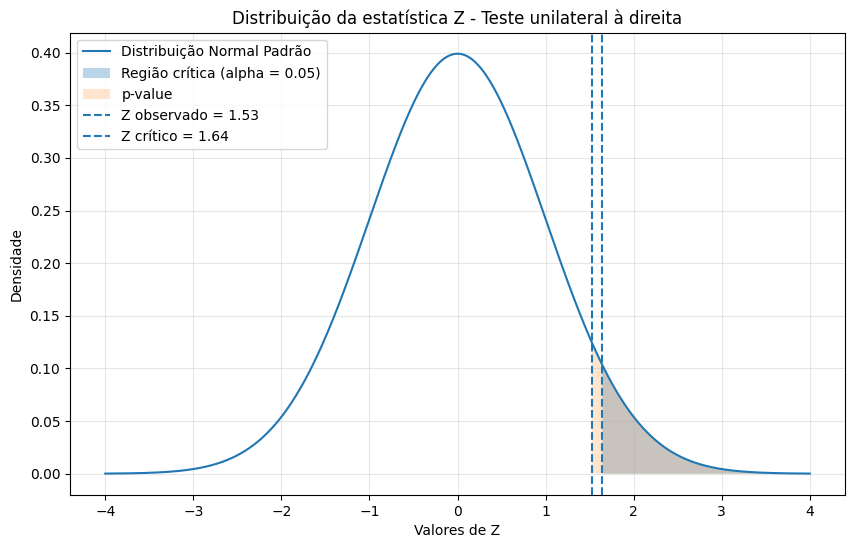


Observação:
O gráfico mostra a distribuição normal padrão usada no teste Z. Como o teste é unilateral
à direita, a região crítica está na cauda direita, a partir de Z crítico = 1.64.
O Z observado foi 1.53, que ficou antes do valor crítico. Além disso, o p-value foi 0.0634,
maior que 0.05. Portanto, não rejeitamos H0 ao nível de significância de 5%.



In [6]:
# 4) Gráfico da distribuição da estatística do teste Z
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Distribuição Normal Padrão')

# Região crítica: cauda direita a partir do Z crítico
x_rejeicao = np.linspace(z_critico, 4, 300)
plt.fill_between(x_rejeicao, stats.norm.pdf(x_rejeicao), alpha=0.3, label='Região crítica (alpha = 0.05)')

# Região do p-value: cauda direita a partir do Z observado
x_pvalor = np.linspace(z_stat, 4, 300)
plt.fill_between(x_pvalor, stats.norm.pdf(x_pvalor), alpha=0.2, label='p-value')

plt.axvline(z_stat, linestyle='--', label=f'Z observado = {z_stat:.2f}')
plt.axvline(z_critico, linestyle='--', label=f'Z crítico = {z_critico:.2f}')

plt.title('Distribuição da estatística Z - Teste unilateral à direita')
plt.xlabel('Valores de Z')
plt.ylabel('Densidade')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

posicao_z = 'dentro da região crítica' if z_stat >= z_critico else 'fora da região crítica'
comparacao_pvalue = 'menor' if p_value < alpha else 'maior ou igual'

mensagem_grafico = f"""
Observação:
O gráfico mostra a distribuição normal padrão usada no teste Z. Como o teste é unilateral
à direita, a região crítica está na cauda direita, a partir de Z crítico = {z_critico:.2f}.
O Z observado foi {z_stat:.2f}, ficando {posicao_z}. Além disso, o p-value foi {p_value:.4f},
{comparacao_pvalue} que alpha = {alpha}. Portanto, {decisao_teste}.

Conclusão final: {conclusao_teste}
"""
print(mensagem_grafico)

